Importando Biblioteca KERAS

In [20]:
import tensorflow
from tensorflow import keras

Extraindo informações do dataset

In [21]:
# Carregando Dataset Fashion MNIST
dataset = keras.datasets.fashion_mnist
((train_imgs, train_labels), (test_imgs, test_labels)) = dataset.load_data()

# separate the dataset: train | test

print(len(train_imgs)) # tamanho conjunto de treino
print(len(test_imgs)) # tamanho conjunto de teste

train_imgs.shape # itens, lines, columns
test_imgs.shape

60000
10000


(10000, 28, 28)

Visualização do conjunto de dados

In [22]:
import matplotlib.pyplot as plt

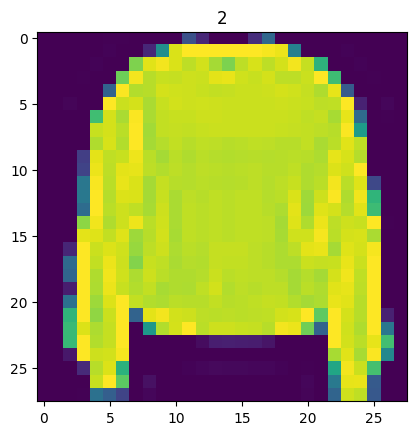

In [54]:
plt.imshow(train_imgs[7])
plt.title(train_labels[7])
plt.show()

# https://github.com/zalandoresearch/fashion-mnist

In [24]:
classes_names = [
 	'Camiseta',
 	'Calça',
 	'Pullover',
 	'Vestido',
 	'Casaco',
 	'Sandalha',
 	'Camisa',
 	'Tênis',
 	'Bolsa',
 	'Bota'
]

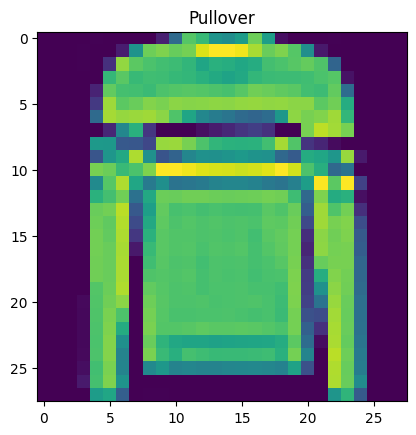

In [53]:
plt.imshow(train_imgs[5])
plt.title(classes_names[train_labels[5]])
plt.show()

TREINAMENTO OTIMIZAÇÃO

In [26]:
train_imgs = train_imgs/255 # Limitando o range para [0 ... 1]
test_imgs = test_imgs/255   # Rede converge e treina mais rapidamente

CRIANDO MODELO

In [47]:
from tensorflow.keras import layers, models

# Declaração do modelo
model = models.Sequential(
    [
        # Camada de compressão para vetor de 784 números
        layers.Flatten(input_shape=(28,28)),

        # Camadas Intermediárias
        layers.Dense(128, activation=tensorflow.nn.relu),
        layers.Dense(64, activation=tensorflow.nn.relu),
        layers.Dropout(0.2), # Camada de dormência: coloca 20% dos neurônios dos 64

        # Camada de Saída
        layers.Dense(10, activation=tensorflow.nn.softmax)
    ]
)

# Compilação do modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Treinamento do modelo

In [48]:
train_stats = model.fit(train_imgs, train_labels,
          epochs=15,       # tentativa de melhoramento com múltiplas épocas
          batch_size=128,   # 32 imagens por vez, todas as 60000 imgs em cada época
          validation_split=0.2 # imagens de validação (estão dentro das de treino) para validar o modelo em cada época
          )

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7765 - loss: 0.6427 - val_accuracy: 0.8448 - val_loss: 0.4351
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8490 - loss: 0.4270 - val_accuracy: 0.8561 - val_loss: 0.3972
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8643 - loss: 0.3805 - val_accuracy: 0.8653 - val_loss: 0.3723
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8717 - loss: 0.3574 - val_accuracy: 0.8743 - val_loss: 0.3496
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8799 - loss: 0.3322 - val_accuracy: 0.8752 - val_loss: 0.3473
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8846 - loss: 0.3186 - val_accuracy: 0.8828 - val_loss: 0.3228
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8881 - loss: 0.3058 - val_accuracy: 0.8849 - val_loss: 0.3215
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8922 - loss: 0.2918 - val_accuracy: 0.

Testar o modelo

In [49]:
# Fazendo predição para todo o conjunto de test
predicao = model.predict(test_imgs)

# Importando numpy para visualizar a maior porbabilidade
import numpy as np

# Printando a predição do modelo com relação a uma imagem
np.argmax(predicao[0]) # 9 = bota

# Verificação com rotulo real
print(f'Predição do modelo: {classes_names[np.argmax(predicao[17])]}')
print(f'Dado Real: {classes_names[test_labels[17]]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predição do modelo: Pullover
Dado Real: Casaco


## Avaliando o modelo

In [50]:
test_loss, test_accuracy = model.evaluate(test_imgs, test_labels)

print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8734 - loss: 0.3576
Test Loss: 0.35755792260169983
Test Accuracy: 0.8733999729156494


## Plotando gráficos de avaliação

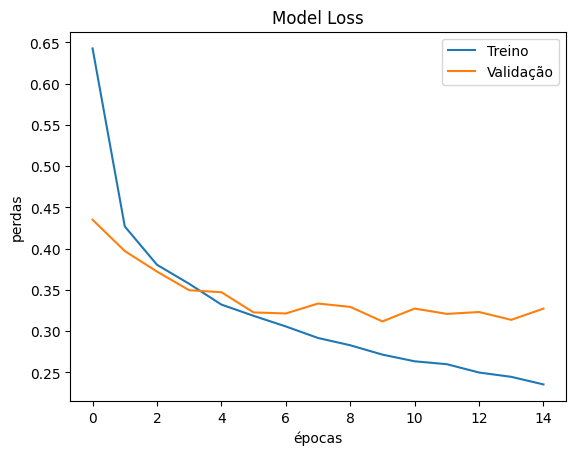

In [55]:
# Overfitting: decorando com o treino
# Underfitting: aprendendo nada pela avaliação das imagens de validação
plt.plot(train_stats.history['loss'])
plt.plot(train_stats.history['val_loss']) # Conjunto de imagens de Validação em cada época depois do batch de imagens de Treino
plt.title('Model Loss')
plt.xlabel('épocas')
plt.ylabel('perdas')
plt.legend(['Treino', 'Validação'])
plt.show()

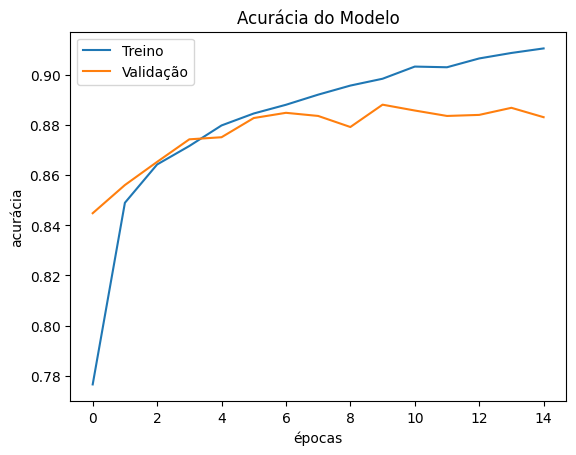

In [52]:
plt.plot(train_stats.history['accuracy'])
plt.plot(train_stats.history['val_accuracy'])
plt.title('Acurácia do Modelo')
plt.xlabel('épocas')
plt.ylabel('acurácia')
plt.legend(['Treino', 'Validação'])
plt.show()

Salvando modelo

In [68]:
from tensorflow.keras.models import load_model

model.save('modelo_salvo.keras')

Importar o modelo

In [69]:
modelo_salvo = load_model('modelo_salvo.keras', custom_objects={'softmax_v2':tensorflow.nn.softmax})

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Testando na prática

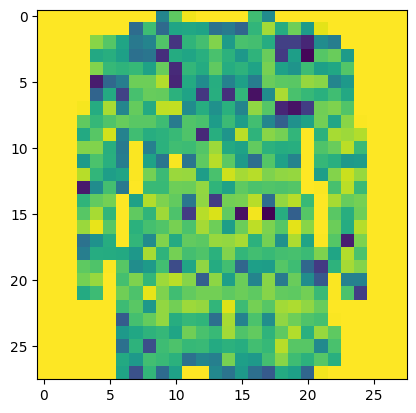

In [70]:
img_url = 'https://lot29.dk/cdn/shop/files/MI-Greek-Motif-Short-Cover-Up-Multicolour_800x.jpg'

img_path = tensorflow.keras.utils.get_file(origin=img_url)

img = tensorflow.keras.utils.load_img(
    img_path,
    target_size=(28,28),
    color_mode='grayscale'
)

plt.imshow(img)
plt.show()

In [71]:
img_array = tensorflow.keras.utils.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array/255.0

In [75]:
predict = modelo_salvo.predict(img_array)
predict = classes_names[np.argmax(predict)]
print('Resultado da predição prática:', predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Resultado da predição prática: Bolsa
